In [44]:
import sys
sys.path.append("../src")

In [45]:
from Tensorflow.connect_Database import connect
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from preprocessing import clean,stopword
import matplotlib.pyplot as plt
import pickle

In [46]:
max_words = 10000
max_len = 80

In [47]:
app =connect()
df = pd.DataFrame(app.load_data_VnExpress())

In [48]:
def process_texts(texts):
    cleaned = [clean(str(t)) for t in texts]
    processed = stopword(cleaned)
    return processed
df['clean_content'] = process_texts(df['content'])

In [49]:
df = df[df['clean_content'].notna() & (df['clean_content'].str.strip() != '') & df['subtopic'].notna()].reset_index(drop=True)

In [50]:
df = df[
    ~df['subtopic'].isin(['Ảnh']) &
    ~df['topic'].isin(['Xe', 'Thể thao'])
]
counts = df['subtopic'].value_counts()
df = df[df['subtopic'].isin(counts[counts >= 1000].index)]
max_count = 1500
df  = (df.groupby('subtopic', group_keys=False, as_index=False).apply(lambda x: x.sample(max_count, replace=True)).reset_index(drop=True))

C:\Users\admin\AppData\Local\Temp\ipykernel_26396\1275450555.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df  = (df.groupby('subtopic', group_keys=False, as_index=False).apply(lambda x: x.sample(max_count, replace=True)).reset_index(drop=True))


In [51]:
X = df['clean_content'].values  
y_sub = df['subtopic'].values

tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(X)

In [52]:
print(tokenizer.word_index) 


{'công': 1, 'thể': 2, 'đầu': 3, 'đồng': 4, 'thành': 5, 'quốc': 6, 'động': 7, 'hàng': 8, 'gia': 9, 'học': 10, 'hiện': 11, 'nam': 12, 'trung': 13, 'nhân': 14, 'trường': 15, 'định': 16, 'phát': 17, 'việt': 18, 'hợp': 19, 'giá': 20, 'thời': 21, 'quan': 22, 'nghiệp': 23, 'tế': 24, 'sản': 25, 'dụng': 26, 'đại': 27, 'sinh': 28, 'triển': 29, 'hội': 30, 'thông': 31, 'hành': 32, 'hai': 33, 'trình': 34, 'dự': 35, 'kết': 36, 'năng': 37, 'thực': 38, 'lý': 39, 'hình': 40, 'doanh': 41, 'cầu': 42, 'xuất': 43, 'thị': 44, 'chủ': 45, 'viên': 46, 'nghệ': 47, 'ảnh': 48, 'mỹ': 49, 'tiếp': 50, 'tác': 51, 'dân': 52, 'thống': 53, 'toàn': 54, 'lực': 55, 'tài': 56, 'hóa': 57, 'chức': 58, 'đường': 59, 'tâm': 60, 'vụ': 61, 'hệ': 62, 'kinh': 63, 'đi': 64, 'giải': 65, 'tỷ': 66, 'gian': 67, 'tổng': 68, '1': 69, 'sĩ': 70, 'độ': 71, 'tiêu': 72, 'nội': 73, 'bệnh': 74, 'bảo': 75, 'khu': 76, 'tập': 77, '9': 78, 'giới': 79, 'phòng': 80, 'giúp': 81, 'đổi': 82, 'điện': 83, 'triệu': 84, 'thu': 85, 'chiến': 86, 'phẩm': 87, '00

In [53]:
from collections import Counter

def counter_word(text_col):
    count = Counter()
    for text in text_col:
        for word in text.split():
            count[word] += 1
    return count

word_count = counter_word(df['clean_content'])


In [54]:
print(word_count.most_common(100))

[('công', 20138), ('thể', 13256), ('đầu', 13069), ('đồng', 12688), ('thành', 11534), ('quốc', 11276), ('động', 10847), ('hàng', 10703), ('gia', 10652), ('học', 10156), ('hiện', 9661), ('nam', 9174), ('trung', 9127), ('nhân', 8746), ('trường', 8648), ('định', 8567), ('phát', 8518), ('việt', 8377), ('hợp', 7825), ('giá', 7560), ('thời', 7518), ('quan', 7265), ('nghiệp', 7249), ('tế', 7159), ('sản', 7108), ('dụng', 7016), ('đại', 7005), ('sinh', 6968), ('triển', 6958), ('hội', 6945), ('thông', 6813), ('hành', 6808), ('hai', 6808), ('trình', 6709), ('dự', 6640), ('kết', 6553), ('năng', 6451), ('thực', 6411), ('lý', 6299), ('hình', 6186), ('doanh', 6131), ('cầu', 6107), ('xuất', 6088), ('thị', 6041), ('chủ', 6003), ('viên', 5999), ('nghệ', 5916), ('ảnh', 5887), ('mỹ', 5781), ('tiếp', 5734), ('tác', 5693), ('dân', 5676), ('thống', 5676), ('toàn', 5533), ('lực', 5494), ('tài', 5210), ('hóa', 5203), ('chức', 5198), ('đường', 5195), ('tâm', 5172), ('vụ', 5167), ('hệ', 5152), ('kinh', 5152), ('đ

In [55]:
print(tokenizer.word_index.items())

dict_items([('công', 1), ('thể', 2), ('đầu', 3), ('đồng', 4), ('thành', 5), ('quốc', 6), ('động', 7), ('hàng', 8), ('gia', 9), ('học', 10), ('hiện', 11), ('nam', 12), ('trung', 13), ('nhân', 14), ('trường', 15), ('định', 16), ('phát', 17), ('việt', 18), ('hợp', 19), ('giá', 20), ('thời', 21), ('quan', 22), ('nghiệp', 23), ('tế', 24), ('sản', 25), ('dụng', 26), ('đại', 27), ('sinh', 28), ('triển', 29), ('hội', 30), ('thông', 31), ('hành', 32), ('hai', 33), ('trình', 34), ('dự', 35), ('kết', 36), ('năng', 37), ('thực', 38), ('lý', 39), ('hình', 40), ('doanh', 41), ('cầu', 42), ('xuất', 43), ('thị', 44), ('chủ', 45), ('viên', 46), ('nghệ', 47), ('ảnh', 48), ('mỹ', 49), ('tiếp', 50), ('tác', 51), ('dân', 52), ('thống', 53), ('toàn', 54), ('lực', 55), ('tài', 56), ('hóa', 57), ('chức', 58), ('đường', 59), ('tâm', 60), ('vụ', 61), ('hệ', 62), ('kinh', 63), ('đi', 64), ('giải', 65), ('tỷ', 66), ('gian', 67), ('tổng', 68), ('1', 69), ('sĩ', 70), ('độ', 71), ('tiêu', 72), ('nội', 73), ('bệnh', 

In [56]:
X_seq = tokenizer.texts_to_sequences(X)

In [57]:
for i in range(10):
    print(f"Text {i}: {X[i][:100]}...")
    print(f"Sequence {i}: {X_seq[i]}")
    print("-"*50)

Text 0: tướng nguyễn phụng tuấn phó tham mưu trưởng quân chủng phòng quân huy bay ảnh đức đồng...
Sequence 0: [367, 193, 2337, 862, 280, 132, 1143, 141, 159, 749, 80, 159, 417, 223, 48, 437, 4]
--------------------------------------------------
Text 1: trung tâm hội chợ triển lãm quốc gia nổi bật mái vòm kim quy diễn triển lãm 80 hành trình độc lập hạ...
Sequence 1: [13, 60, 30, 868, 29, 725, 6, 9, 295, 618, 657, 1996, 443, 126, 93, 29, 725, 461, 32, 34, 371, 168, 743, 559, 48, 1366]
--------------------------------------------------
Text 2: tuyến lê hồng phong ngọc hà lớp barie cứng mềm dựng kiểm soát phương tiện dân đi tuyến phố cấm hoàn ...
Sequence 2: [270, 525, 502, 335, 543, 125, 537, 6532, 1150, 767, 174, 252, 375, 107, 380, 52, 64, 270, 186, 885, 171, 54, 121, 208, 61, 121, 340, 99, 183, 191, 398, 258, 31, 1039, 98, 698, 884, 349, 556, 8, 1167, 2019, 174, 1253, 189, 1860, 1738, 1427]
--------------------------------------------------
Text 3: 30 quân nhân nga bồng súng tiến lễ đ

In [58]:
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating= 'post')

In [59]:
X_pad.shape

(58500, 80)

In [60]:
X_pad[1]

array([  13,   60,   30,  868,   29,  725,    6,    9,  295,  618,  657,
       1996,  443,  126,   93,   29,  725,  461,   32,   34,  371,  168,
        743,  559,   48, 1366,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0])

In [61]:
word_index = tokenizer.word_index

In [62]:
reverse_word_index = dict([(idx, word) for (word, idx) in word_index.items()])

In [63]:
def decode(sequence):
    return " ".join([reverse_word_index.get(idx, "?") for idx in sequence])

In [64]:
decode_text = decode(X_pad[10])

In [65]:
print(decode_text)

gian trưng bày thiết kế hiện đại kết hợp hiện vật hình ảnh liệu lịch sử công nghệ trình chiếu 3d mapping thực tế ảo hologram ứng dụng trí tuệ nhân trải nghiệm công ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?


In [66]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_sub)
y_one_hot = to_categorical(y_encoded)
y_one_hot

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [67]:
print("Original labels:")
print(y_sub)

print("\nLabel encoded:")
print(y_encoded)

print("\nOne-hot encoded:")
print(y_one_hot)

Original labels:
['80 năm Quốc khánh' '80 năm Quốc khánh' '80 năm Quốc khánh' ... 'Ẩm thực'
 'Ẩm thực' 'Ẩm thực']

Label encoded:
[ 0  0  0 ... 38 38 38]

One-hot encoded:
[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y_one_hot, test_size=0.2, random_state=42
)

In [69]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(y_one_hot.shape[1], activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [70]:
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 80, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 39)             │         2,535 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,422,375 (5.43 MB)

 Trainable params: 1,422,375 (5.43 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[stopping]
)

Epoch 1/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 169s 218ms/step - accuracy: 0.0257 - loss: 3.6643 - val_accuracy: 0.0265 - val_loss: 3.6620
Epoch 2/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 134s 183ms/step - accuracy: 0.0379 - loss: 3.5751 - val_accuracy: 0.0597 - val_loss: 3.3354
Epoch 3/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 137s 187ms/step - accuracy: 0.0741 - loss: 3.2162 - val_accuracy: 0.1157 - val_loss: 2.9909
Epoch 4/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 139s 190ms/step - accuracy: 0.1278 - loss: 2.8648 - val_accuracy: 0.1989 - val_loss: 2.6015
Epoch 5/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 138s 188ms/step - accuracy: 0.2303 - loss: 2.4574 - val_accuracy: 0.3272 - val_loss: 2.1779
Epoch 6/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 141s 193ms/step - accuracy: 0.3547 - loss: 2.0547 - val_accuracy: 0.4423 - val_loss: 1.8222
Epoch 7/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 142s 195ms/step - accuracy: 0.4531 - loss: 1.7440 - val_accuracy: 0.4998 - val_loss: 1.6529
Epoch 8/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 145s 199ms/step - accuracy: 0.5207 -

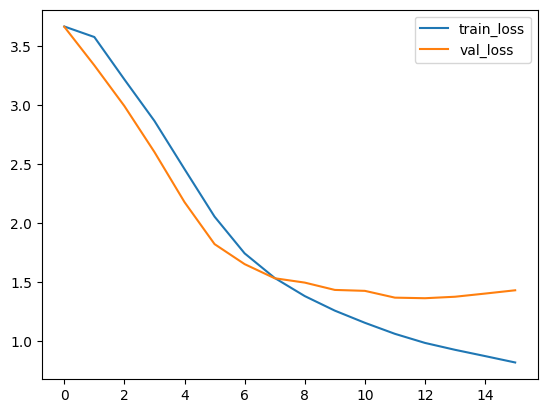

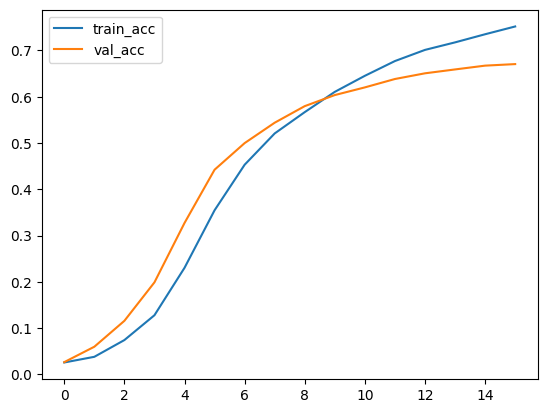

In [72]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [73]:
model.save_weights("../models/Tensorflow/models.weights.h5")
with open("../models/Tensorflow/tokenizers.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("../models/Tensorflow/label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [74]:
model.load_weights("../models/Tensorflow/models.weights.h5")
tokenizer = pickle.load(open("../models/Tensorflow/tokenizers.pkl", "rb"))
label_encoder = pickle.load(open("../models/Tensorflow/label_encoder.pkl", "rb"))

In [103]:
df_Reddit = pd.DataFrame(app.load_data())

In [104]:
df_Reddit['clean_content'] = process_texts(df_Reddit['content'])
df_result = df_Reddit.dropna(subset=['clean_content']).reset_index(drop=True)
df_Reddit = df_Reddit[
    df_Reddit['clean_content'].notna() &
    (df_Reddit['clean_content'].str.strip() != "") &
    (df_Reddit['clean_content'].str.lower() != "none")
].reset_index(drop=True)
contents = df_Reddit['clean_content'].dropna().tolist()


In [105]:
X_new = tokenizer.texts_to_sequences(contents)
X_new = pad_sequences(X_new, maxlen=max_len, padding='post', truncating='post')

predictions  = model.predict(X_new)
categories = label_encoder.inverse_transform(predictions .argmax(axis=1))

286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


In [106]:
df_Reddit['label'] =categories

In [121]:
print(contents[130])
print(X_new[130])

mấy hot gpt genemi claude grok bọn tàu dịch sượng voz vn mấy kia toàn seeder mấy mấy dịch tệ bọn mục đích dốt tiếng 1 kênh yt tiếng đọc sub ko nghĩa kiếm chất dịch
[1704 2496 2556 3347 3574 3287  476  103  982 1704 1765   54 1704 1704
  103  912 3287  179  990  201   69 1148  201  790 5045  450  652  110
  103    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0]


In [126]:
check = tokenizer.index_word.get(2556 , None)
check

'gpt'

In [122]:
df_Reddit.head(5)

,link,author,comments,content,date,image_link,subreddit,title,upvotes,video_link,clean_content,label
0,https://www.reddit.com/r/TroChuyenLinhTinh/com...,Friendly-Lie5849,37,Bộ phim tuyên truyền chủ nghĩa dân tộc cực đoa...,2025-08-22 07:25:50,None,TroChuyenLinhTinh,Những gì đang diễn ra ở Trung Quốc đang dần lặ...,157,None,phim tuyên truyền chủ nghĩa dân tộc cực đoan m...,Phim
1,https://www.reddit.com/r/vozforums/comments/1m...,TinNT0409,1,"Chào mọi người, đợt này mình có dùng Mathpix đ...",2025-08-22 07:23:33,https://external-preview.redd.it/kqhxR96oyl5gx...,vozforums,Phần mềm quét công thức sang Word miễn phí tha...,2,None,chào đợt mathpix quét công thức đc 10 lượt viế...,Tư vấn
2,https://www.reddit.com/r/TroChuyenLinhTinh/com...,Weekly_Top7078,3,Trước kì kinh bao nhiêu ngày thì an toàn?,2025-08-22 07:07:46,None,TroChuyenLinhTinh,Ngày an toàn,0,None,kì kinh bao nhiêu an toàn,Tổ ấm
3,https://www.reddit.com/r/VietNamNation/comment...,Ambitious-Fan-9831,18,ờm bỏ qua tỉ lệ gái đẹp ra thì tao thấy bề nổi...,2025-08-22 07:04:09,None,VietNamNation,Thái Lan có phải là 1 hình mẫu nước đáng sống ...,16,None,ờm tỉ lệ gái đẹp tao bề nổi thái lọ cánh tả số...,Nhịp sống
4,https://www.reddit.com/r/vozforums/comments/1m...,Nicklas0704,3,"Hi các bác, e làm mmo có dư 1 ít, cụ thể là kh...",2025-08-22 14:03:21,None,vozforums,Hiện tại nên bỏ tiền vào đâu ?,0,None,hi e mmo dư 1 cụ thể 10 tỉ tham gia đầu hiện e...,Doanh nghiệp


In [127]:
for idx, row in df_Reddit.head(500).iterrows():
    print(f"Author: {row['author']}")
    print(f"subreddit: {row['subreddit']}")
    print(f"Content: {row['content'][:200]}...")
    print(f"Label: {row['label']}")
    print("-"*60)

Author: Friendly-Lie5849
subreddit: TroChuyenLinhTinh
Content: Bộ phim tuyên truyền chủ nghĩa dân tộc cực đoan Mưa Đỏ aka Máu Kinh đang được truyền thông, dư luận viên, bò đỏ, Sô-Vanh con tung hê hết lời. Phim hiện đã thu về 28 tỷ đồng vào ngày đầu công chiếu là ...
Label: Phim
------------------------------------------------------------
Author: TinNT0409
subreddit: vozforums
Content: Chào mọi người, đợt này mình có dùng Mathpix để quét công thức nhưng đc có 10 lượt nên Viết luôn app thay thế miễn phí [AuraLateX](https://auravsoftware.com/chuyen-cong-thuc-toan-sang-word/)...
Label: Tư vấn
------------------------------------------------------------
Author: Weekly_Top7078
subreddit: TroChuyenLinhTinh
Content: Trước kì kinh bao nhiêu ngày thì an toàn?...
Label: Tổ ấm
------------------------------------------------------------
Author: Ambitious-Fan-9831
subreddit: VietNamNation
Content: ờm bỏ qua tỉ lệ gái đẹp ra thì tao thấy bề nổi của Thái lọ có nhiều cái khá cánh tả đáng để sống.
Chín

In [124]:
df_Reddit['label'].value_counts()

label
80 năm Quốc khánh    808
Bài học sống         664
Tổ ấm                618
Nhịp sống            582
Sách                 522
Giới sao             468
Cuộc sống đó đây     446
Tin tức              390
Tư liệu              357
Du học               302
Tư vấn               295
Phim                 271
Điểm đến             239
Ẩm thực              218
Hồ sơ phá án      185
Doanh nghiệp         180
Kỷ nguyên mới        178
AI                   178
Nhạc                 169
Sống khỏe            166
Chuyển đổi số        165
Thời trang           147
Chính trị            139
Quốc tế              136
Thiết bị             123
Quân sự              111
Không gian sống      111
Vĩ mô                109
Kinh tế vùng         109
Ebank                101
Hàng hóa              97
NetZero               94
Thị trường            92
Các bệnh              80
Đổi mới sáng tạo      80
Phân tích             63
Giao thông            62
Vaccine               61
Chứng khoán           26
Name: count, dtype:

In [125]:
df_Reddit[df_Reddit['label'] == "AI"]


,link,author,comments,content,date,image_link,subreddit,title,upvotes,video_link,clean_content,label
51,https://www.reddit.com/r/vozforums/comments/1m...,nickybalboa,3,Hello mấy fen. Tôi hiện tại đang làm dev ở big...,2025-08-21 19:24:41,None,vozforums,Kiếm job remote ở nước ngoài,5,None,hello mấy fen hiện dev big tech mẽo đường vn t...,AI
78,https://www.reddit.com/r/vozforums/comments/1m...,FewBusiness8177,0,Có bác nào từng làm về hardware test engineer ...,2025-08-21 15:23:31,None,vozforums,Kinh nghiệm đi làm,0,None,hardware test engineer review vị trí đi,AI
91,https://www.reddit.com/r/vozforums/comments/1m...,Valuable-Explorer899,25,Mình làm công cụ này vì cá nhân mình thích đọc...,2025-08-21 12:20:39,https://preview.redd.it/gfanj9yv7dkf1.png?auto...,vozforums,"Hello, có ai thích đọc bài viết dài, chuyên sâ...",47,None,công cụ cá nhân đọc viết chuyên sâu vấn đề ngo...,AI
113,https://www.reddit.com/r/vozforums/comments/1m...,Cuongsmjle,0,Có tool hỗ trợ đầu tư chứng khoán bằng GPT 5 a...,2025-08-21 08:52:41,None,vozforums,Tool đầu tư chứng khoán Việt Nam,3,None,tool hỗ trợ đầu chứng khoán gpt 5 tham khảo mụ...,AI
114,https://www.reddit.com/r/VietNamNation/comment...,Cuongsmjle,1,Có tool hỗ trợ đầu tư chứng khoán bằng GPT 5 a...,2025-08-21 08:51:16,None,VietNamNation,Tool đầu tư chứng khoán Việt Nam,1,None,tool hỗ trợ đầu chứng khoán gpt 5 tham khảo mụ...,AI
...,...,...,...,...,...,...,...,...,...,...,...,...
8907,https://www.reddit.com/r/vozforums/comments/1o...,VietTalk_201,16,Hi mọi người. Post trước mình có nhiều comment...,2025-10-16 14:44:20,None,vozforums,Cùng cải thiện giao tiếp tiếng anh,16,None,hi post comments đồng việt nam hội giao tiếp c...,AI
8942,https://www.reddit.com/r/vozforums/comments/1o...,mrmonz79,2,Ảnh minh họa\n\nĐó giờ em update bằng app Smar...,2025-10-16 19:51:16,https://preview.redd.it/t2ubrced3jvf1.jpeg?aut...,vozforums,Cứu em: Đt samsung bị kẹt ở download mode,1,None,ảnh minh họa update app smart switch pc ok lắm...,AI
8979,https://www.reddit.com/r/vozforums/comments/1o...,Same-Profession3893,2,"Trường hợp bị thay sdt,mail và mk thì làm sao ...",2025-10-17 03:27:13,None,vozforums,Bị hack nick fb,1,None,trường hợp thay sdt mail mk nick fb,AI
9091,https://www.reddit.com/r/vozforums/comments/1o...,Jovaniac,11,"Mình học ngành ngôn ngữ anh, còn đang nợ 1 cái...",2025-10-17 19:31:34,None,vozforums,Thất nghiệp,3,None,học ngành ngôn ngữ nợ 1 tiếng pháp b1 kiện ngh...,AI
